
# Running d-prime after Rev Set A switch

This notebook finds mice whose last three recorded days used **Rev Set A**, collects the last four days after the switch, trims trailing no-lick trials per session, computes a 20-trial running d-prime, and fits a robust Theil–Sen regression to the post-switch learning curve. Plots are saved to `outputs/dprime_learning/`.

Additional metrics:
- Time to criterion: first running window with d' ≥ 2 (20-trial window), reported as the window-ending trial index.
- Within-day learning: max–min d' per post-switch day; four day-specific columns plus a summed gain column.

Cue-set labels are read from the JSON logs referenced by each HDF5 `metadata.source_file` because HDF5 alone does not store `cueSet`.


In [1]:

from pathlib import Path
from datetime import datetime, date
import re
import pandas as pd
import numpy as np
from scipy.stats import norm, theilslopes
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:

HDF5_ROOT = Path("/groups/spruston/home/moharb/DELTA_Behavior/outputs/hdf5")
OUTPUT_DIR = Path("/groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WINDOW_SIZE = 30


In [3]:

cue_pattern = re.compile(r'"cueSet"\s*:\s*"([^"]+)"')

def extract_cue_set(json_path: Path, chunk_size: int = 1024 * 1024):
    buffer = ""
    try:
        with json_path.open("r", encoding="utf-8") as f:
            for chunk in iter(lambda: f.read(chunk_size), ""):
                buffer += chunk
                match = cue_pattern.search(buffer)
                if match:
                    return match.group(1)
                buffer = buffer[-100:]
    except FileNotFoundError:
        return None
    return None

def build_session_table(root: Path) -> pd.DataFrame:
    records = []
    pattern = re.compile(r"Log\s+(BM\d+)\s+(\d{4}-\d{2}-\d{2})\s+session\s+(\d+)", re.IGNORECASE)
    for h5_path in sorted(root.rglob("*.h5")):
        try:
            md = pd.read_hdf(h5_path, "metadata")
        except Exception as exc:
            print(f"Skipping {h5_path}: {exc}")
            continue
        source_file = Path(str(md.get("source_file", "")))
        match = pattern.search(source_file.stem)
        if not match:
            continue
        animal = match.group(1).upper()
        date_val = datetime.strptime(match.group(2), "%Y-%m-%d").date()
        session = int(match.group(3))
        cue_set = extract_cue_set(source_file)
        records.append({
            "animal": animal,
            "date": date_val,
            "session": session,
            "cue_set": cue_set,
            "h5_path": h5_path,
            "json_path": source_file,
        })
    cols = ["animal", "date", "session", "cue_set", "h5_path", "json_path"]
    return pd.DataFrame(records, columns=cols)

def daily_cue_table(sessions: pd.DataFrame) -> pd.DataFrame:
    if sessions.empty:
        return pd.DataFrame(columns=["animal", "date", "cue_set"])
    return (
        sessions
        .groupby(["animal", "date"], as_index=False)
        .agg(cue_set=("cue_set", lambda x: ", ".join(sorted({c for c in x if pd.notna(c)})) or None))
        .sort_values(["animal", "date"])
    )

def animals_with_last_three_rev(daily: pd.DataFrame):
    animals = []
    for animal, g in daily.groupby("animal"):
        g = g.sort_values("date")
        if len(g) < 3:
            continue
        last_three = g.tail(3)["cue_set"].fillna("")
        if all("rev" in c.lower() for c in last_three):
            animals.append(animal)
    return animals

def first_rev_date(daily: pd.DataFrame, animal: str):
    g = daily[daily["animal"] == animal]
    rev_dates = [d for d, c in zip(g["date"], g["cue_set"]) if isinstance(c, str) and "rev" in c.lower()]
    return min(rev_dates) if rev_dates else None


In [4]:

def drop_trailing_no_licks(trials: pd.DataFrame) -> pd.DataFrame:
    total_licks = trials[["num_licks_pre", "num_licks_reward"]].fillna(0).sum(axis=1)
    nonzero_idx = np.flatnonzero(total_licks.to_numpy() > 0)
    if len(nonzero_idx) == 0:
        return trials.iloc[:0]
    last_keep = nonzero_idx[-1]
    return trials.iloc[: last_keep + 1].copy()

def compute_dprime(hit_rate: float, fa_rate: float) -> float:
    eps = 1e-4
    hit = np.clip(hit_rate, eps, 1 - eps)
    fa = np.clip(fa_rate, eps, 1 - eps)
    return norm.ppf(hit) - norm.ppf(fa)

def compute_running_dprime(trials: pd.DataFrame, window: int = 20) -> pd.DataFrame:
    records = []
    if len(trials) < window:
        return pd.DataFrame()
    for start in range(0, len(trials) - window + 1):
        window_df = trials.iloc[start : start + window]
        rewarding = window_df[window_df["is_rewarding"] == True]
        non_rewarding = window_df[window_df["is_rewarding"] == False]
        n_hit = len(rewarding)
        n_fa = len(non_rewarding)
        if n_hit == 0 or n_fa == 0:
            continue
        hit_rate = (rewarding["licked"] == True).mean()
        fa_rate = (non_rewarding["licked"] == True).mean()
        hit_rate = (hit_rate * n_hit + 0.5) / (n_hit + 1)
        fa_rate = (fa_rate * n_fa + 0.5) / (n_fa + 1)
        d_prime_val = compute_dprime(hit_rate, fa_rate)
        records.append({
            "trial_index": window_df["trial_global_index"].iloc[-1],
            "d_prime": d_prime_val,
            "hit_rate": hit_rate,
            "fa_rate": fa_rate,
            "date": window_df["date"].iloc[-1],
        })
    return pd.DataFrame(records)

def fit_robust_slope(df: pd.DataFrame):
    x = df["trial_index"].to_numpy()
    y = df["d_prime"].to_numpy()
    slope, intercept, _, _ = theilslopes(y, x)
    return float(slope), float(intercept)

def time_to_criterion(df: pd.DataFrame, threshold: float = 2.0):
    if df.empty:
        return np.nan
    mask = df["d_prime"] >= threshold
    if not mask.any():
        return np.nan
    return float(df.loc[mask, "trial_index"].iloc[0])

def within_day_gains(df: pd.DataFrame, ordered_dates):
    gains = []
    for d in ordered_dates:
        day_df = df[df["date"] == d]
        if day_df.empty:
            gains.append(np.nan)
        else:
            gains.append(float(day_df["d_prime"].max() - day_df["d_prime"].min()))
    return gains


In [5]:

def load_trials_for_sessions(session_rows: pd.DataFrame):
    rows = []
    trial_idx = 0
    for _, row in session_rows.sort_values(["date", "session"]).iterrows():
        trials = pd.read_hdf(row["h5_path"], "events/Trials")
        trials = drop_trailing_no_licks(trials)
        for _, t in trials.iterrows():
            rows.append({
                "animal": row["animal"],
                "date": row["date"],
                "session": row["session"],
                "trial_in_session": int(t["trial_id"]),
                "trial_global_index": trial_idx,
                "is_rewarding": bool(t["is_rewarding"]),
                "licked": bool(t.get("licked", False)),
                "correct": bool(t.get("correct", False)),
            })
            trial_idx += 1
    return pd.DataFrame(rows)

def plot_dprime(animal: str, df: pd.DataFrame, slope: float, intercept: float, out_dir: Path) -> Path:
    plt.figure(figsize=(8, 4))
    dates = df["date"].unique()
    palette = dict(zip(dates, sns.color_palette("viridis", len(dates))))
    for d in dates:
        mask = df["date"] == d
        plt.plot(df.loc[mask, "trial_index"], df.loc[mask, "d_prime"], marker="o", linestyle="-", label=str(d), color=palette[d])
    x_line = np.array([df["trial_index"].min(), df["trial_index"].max()])
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, color="black", linestyle="--", label=f"Theil-Sen slope={slope:.3f}")
    plt.axhline(0, color="gray", linewidth=1, linestyle=":")
    plt.xlabel("Trial index (post-switch)")
    plt.ylabel("20-trial running d'")
    plt.title(f"{animal}: learning after Rev Set A switch")
    plt.legend()
    plt.tight_layout()
    out_path = out_dir / f"{animal}_running_dprime.png"
    plt.savefig(out_path, dpi=200)
    plt.close()
    return out_path


In [6]:

# Build session tables and find animals whose last three days are Rev Set A
sessions = build_session_table(HDF5_ROOT)
if sessions.empty:
    print("No sessions found under outputs/hdf5. Check HDF5_ROOT and file names.")
daily = daily_cue_table(sessions)
rev_animals = animals_with_last_three_rev(daily)
rev_animals


['BM32', 'BM33', 'BM35', 'BM36', 'BM37', 'BM38']

In [7]:

results = []
plots = []

for animal in rev_animals:
    rev_start = first_rev_date(daily, animal)
    if rev_start is None:
        continue
    animal_daily = daily[daily["animal"] == animal]
    post_switch_dates = animal_daily[animal_daily["date"] >= rev_start]["date"].unique()
    if len(post_switch_dates) == 0:
        continue
    last_dates = sorted(post_switch_dates)[-3:]
    animal_sessions = sessions[(sessions["animal"] == animal) & (sessions["date"].isin(last_dates))]
    trial_df = load_trials_for_sessions(animal_sessions)
    if trial_df.empty:
        continue
    running = compute_running_dprime(trial_df, window=WINDOW_SIZE)
    if running.empty:
        continue
    slope, intercept = fit_robust_slope(running)
    fig_path = plot_dprime(animal, running, slope, intercept, OUTPUT_DIR)

    # Time to criterion (d' >= 2)
    tt_crit = time_to_criterion(running, threshold=2.0)

    # Within-day gains (max-min per day)
    gains = within_day_gains(running, last_dates)
    while len(gains) < 4:
        gains.append(np.nan)
    gain_sum = float(np.nansum(gains)) if len(gains) else np.nan

    results.append({
        "animal": animal,
        "rev_start": rev_start,
        "dates_used": ", ".join(str(d) for d in last_dates),
        "num_trials": len(trial_df),
        "num_windows": len(running),
        "slope": slope,
        "intercept": intercept,
        "time_to_criterion_trial": tt_crit,
        "within_day_gain_1": gains[0],
        "within_day_gain_2": gains[1],
        "within_day_gain_3": gains[2],
        "within_day_gain_sum": gain_sum,
        "figure": str(fig_path),
    })
    plots.append(fig_path)

summary = pd.DataFrame(results).sort_values("animal")
summary


,animal,rev_start,dates_used,num_trials,num_windows,slope,intercept,time_to_criterion_trial,within_day_gain_1,within_day_gain_2,within_day_gain_3,within_day_gain_sum,figure
0,BM32,2025-06-28,"2025-06-28, 2025-06-29, 2025-06-30",1226,1197,0.001890,0.019690,606.0,2.862240,3.226200,2.957438,9.045877,/groups/spruston/home/moharb/DELTA_Behavior/ou...
1,BM33,2025-08-03,"2025-08-03, 2025-08-04, 2025-08-05",1032,1003,0.001714,-0.739395,886.0,2.710051,2.557884,3.210957,8.478892,/groups/spruston/home/moharb/DELTA_Behavior/ou...
2,BM35,2025-09-24,"2025-09-24, 2025-09-25, 2025-09-26",1171,1142,0.002345,-0.213941,501.0,2.340500,3.130637,3.267327,8.738465,/groups/spruston/home/moharb/DELTA_Behavior/ou...
3,BM36,2025-09-24,"2025-09-24, 2025-09-25, 2025-09-26",1881,1852,0.001934,-1.434306,1209.0,2.483455,3.475941,3.889966,9.849362,/groups/spruston/home/moharb/DELTA_Behavior/ou...
4,BM37,2025-10-11,"2025-10-11, 2025-10-12, 2025-10-13",1140,1111,0.002629,-1.423463,1045.0,3.165560,2.103993,3.707844,8.977398,/groups/spruston/home/moharb/DELTA_Behavior/ou...
5,BM38,2025-10-11,"2025-10-11, 2025-10-12, 2025-10-13",1142,1113,0.002879,-0.466209,498.0,3.561657,4.136998,4.128073,11.826728,/groups/spruston/home/moharb/DELTA_Behavior/ou...


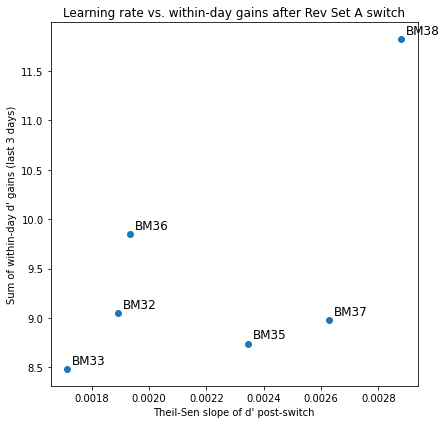

In [8]:
# plot slope vs. within_day_gain_sum
plt.figure(figsize=(6, 6))
plt.scatter(summary["slope"], summary["within_day_gain_sum"])
plt.xlabel("Theil-Sen slope of d' post-switch")
plt.ylabel("Sum of within-day d' gains (last 3 days)")
plt.title("Learning rate vs. within-day gains after Rev Set A switch")
plt.tight_layout()
# anotate point labels  
for i, animal in enumerate(summary["animal"]):
    plt.annotate(animal, (summary["slope"].iloc[i], summary["within_day_gain_sum"].iloc[i]),
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=12)
plt.show()

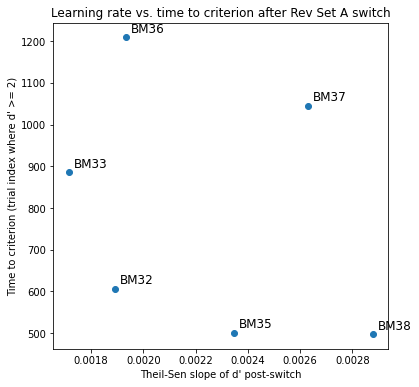

In [9]:
# plot slope vs.time to criterion
plt.figure(figsize=(6, 6))
plt.scatter(summary["slope"], summary["time_to_criterion_trial"])
plt.xlabel("Theil-Sen slope of d' post-switch")
plt.ylabel("Time to criterion (trial index where d' >= 2)")
plt.title("Learning rate vs. time to criterion after Rev Set A switch")
# anotate point labels  
for i, animal in enumerate(summary["animal"]):
    plt.annotate(animal, (summary["slope"].iloc[i], summary["time_to_criterion_trial"].iloc[i]),
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=12)
plt.show()

/groups/spruston/home/moharb/mambaforge/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


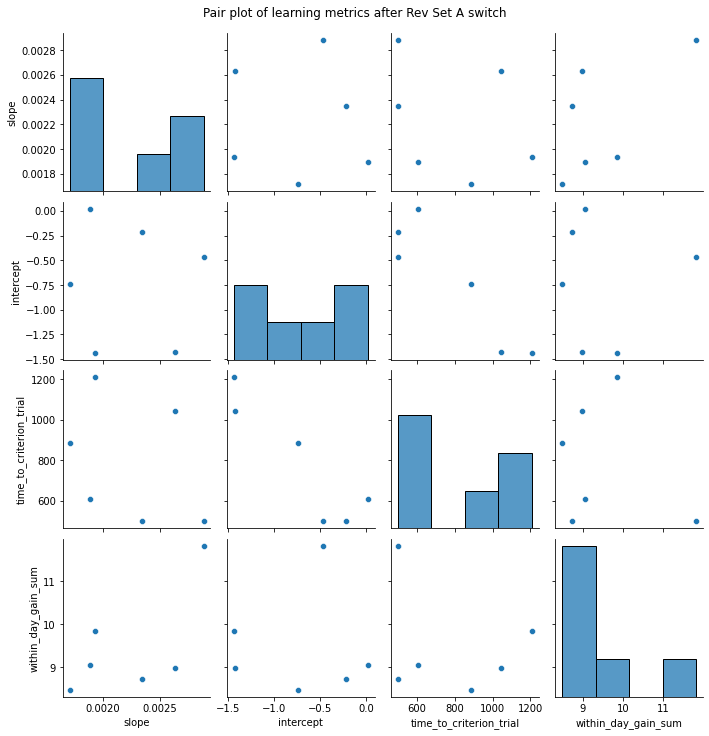

In [10]:
# pair plot of slope	intercept	time_to_criterion_trial and within_day_gain_sum
sns.pairplot(summary[["slope", "intercept", "time_to_criterion_trial", "within_day_gain_sum"]])
plt.suptitle("Pair plot of learning metrics after Rev Set A switch", y=1.02)
plt.show()  

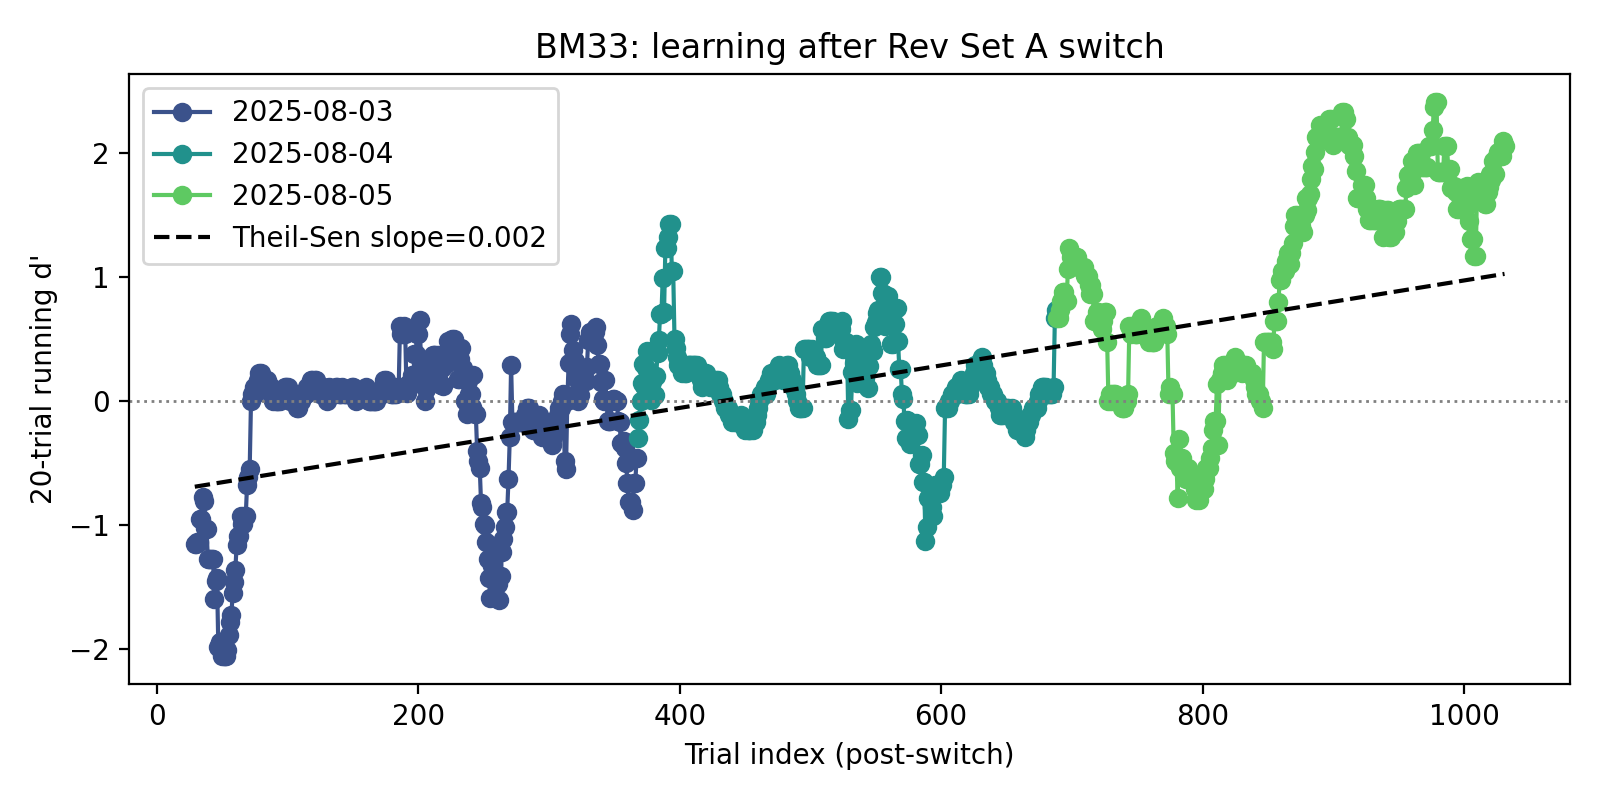

In [11]:

# Display example running d-prime for the first animal (inline)
if plots:
    from IPython.display import Image, display
    display(Image(filename=str(plots[1])))



### Notes
- Trailing trials in a session with zero licks are removed before computing d-prime to ignore periods when the animal is just running.
- D-prime uses 20-trial windows spanning reward and non-reward trials, with log-linear smoothing to avoid infinite values.
- Robust slope uses Theil–Sen (`scipy.stats.theilslopes`).
- Time-to-criterion is the first running window with d' ≥ 2, reported as the window-ending trial index.
- Within-day gain = max d' − min d' per post-switch day; summed across the days used.
- Plots are saved in `outputs/dprime_learning/` as `BMxx_running_dprime.png`.
